# LIBERO v1 dataset exploration

Raw look at `datasets/libero/v1/`. Three splits × 10 tasks × 50 demos × 3 seeds × 10 progress bins = 45,000 trials.

Sections:
1. Load manifests
2. Summary stats (totals, failure-mode + joint distribution, per-task counts)
3. Distributions: `traj_progress`, contact counts, `pre_qvel_norm`
3a. **Why LIBERO contact clouds look noisy** — entity-level baseline filter, raw vs filtered diagnostic
4. Single-trial viewer (pick by index → show all images + state + contacts)
5. RGB grid (many trials at once)
6. **Demo timeline** — all 30 samples for one demo, ordered + plotted on the demo's progress axis
7. Whole-split contact-cloud overlay (still raw — apply the §3a filter for a clean view)

No advanced analysis here — just look at the data.

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(REPO_ROOT)
sys.path.insert(0, REPO_ROOT)

ROOT = "datasets/libero/v1"
SPLITS = ["libero_spatial", "libero_object", "libero_goal"]

# Pretty wide tables in pandas
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 160)
print("cwd:", os.getcwd())

cwd: /home/aaron/workspace/FailBench


## 1. Load manifests

In [2]:
frames = []
for s in SPLITS:
    df = pd.read_csv(f"{ROOT}/{s}/manifest.csv")
    df["_split"] = s
    frames.append(df)
manifest = pd.concat(frames, ignore_index=True)
print(f"{len(manifest)} total rows")
manifest.head(3)

45000 total rows


,experiment_id,split,task_id,task,demo_key,traj_id,seed,bin_idx,traj_progress,failure_mode,failure_joints,failure_prob,num_contacts,had_any_collision,impacted_geom_ids,pre_qvel_norm,npz_file,_split
0,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial,libero_spatial__pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and...,pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the...,demo_0,0,985902766,0,0.0899,GRIPPER_OPEN,NaN,0.25,0,False,NaN,0.8981,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial
1,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial,libero_spatial__pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and...,pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the...,demo_0,0,2126267328,1,0.1772,SINGLE_JOINT,joint2,0.18,831,True,7;72;74;75;77;78;169;170;171;172;173;174;175;176;177;178;179;180;181;182;183...,1.1666,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial
2,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial,libero_spatial__pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and...,pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the...,demo_0,0,1976801033,2,0.2871,SINGLE_JOINT,joint4,0.13,804,True,7;72;77;169;171;179;182;183;184;185;186;187;189;193,0.6347,exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_...,libero_spatial


In [3]:
print("Columns:")
for c in manifest.columns:
    print(f"  {c:25s} dtype={manifest[c].dtype}")

Columns:
  experiment_id             dtype=object
  split                     dtype=object
  task_id                   dtype=object
  task                      dtype=object
  demo_key                  dtype=object
  traj_id                   dtype=int64
  seed                      dtype=int64
  bin_idx                   dtype=int64
  traj_progress             dtype=float64
  failure_mode              dtype=object
  failure_joints            dtype=object
  failure_prob              dtype=float64
  num_contacts              dtype=int64
  had_any_collision         dtype=bool
  impacted_geom_ids         dtype=object
  pre_qvel_norm             dtype=float64
  npz_file                  dtype=object
  _split                    dtype=object


## 2. Summary stats

In [4]:
manifest.groupby("split").agg(
    trials=("experiment_id", "count"),
    tasks=("task", "nunique"),
    demos=("demo_key", "nunique"),
    seeds=("seed", "nunique"),
    bins=("bin_idx", "nunique"),
    median_contacts=("num_contacts", "median"),
)

,trials,tasks,demos,seeds,bins,median_contacts
split,,,,,,
libero_goal,15000,10,50,15000,10,557.5
libero_object,15000,10,50,15000,10,3104.0
libero_spatial,15000,10,50,15000,10,614.0


In [5]:
fmode_split = pd.crosstab(manifest["failure_mode"], manifest["split"], margins=True, margins_name="TOTAL")
fmode_split

split,libero_goal,libero_object,libero_spatial,TOTAL
failure_mode,,,,
ALL_JOINTS,1271,1157,1190,3618
GRIPPER_OPEN,3777,3800,3760,11337
MULTI_JOINT,1330,1354,1340,4024
SINGLE_JOINT,6431,6463,6361,19255
SLIPPERY_GRIP,2191,2226,2349,6766
TOTAL,15000,15000,15000,45000


In [6]:
j = manifest[manifest["failure_joints"] != ""].copy()
pd.crosstab(j["failure_joints"], j["split"], margins=True, margins_name="TOTAL").sort_values("TOTAL", ascending=False)

split,libero_goal,libero_object,libero_spatial,TOTAL
failure_joints,,,,
TOTAL,7761,7817,7701,23279
joint2,2778,2699,2613,8090
joint4,1871,1892,1943,5706
joint6,1024,1100,1081,3205
"joint2,joint4",742,756,776,2274
"joint4,joint6",588,598,564,1750
joint1,443,463,422,1328
joint7,315,309,302,926


In [7]:
# Trials per task per split — should all be 1500 (50 demos × 3 seeds × 10 bins)
pivot = manifest.groupby(["split", "task"]).size().unstack("split", fill_value=0)
pivot.style.background_gradient(axis=None) if hasattr(pivot, "style") else pivot

split,libero_goal,libero_object,libero_spatial
task,,,
open_the_middle_drawer_of_the_cabinet,1500,0,0
open_the_top_drawer_and_put_the_bowl_inside,1500,0,0
pick_up_the_alphabet_soup_and_place_it_in_the_basket,0,1500,0
pick_up_the_bbq_sauce_and_place_it_in_the_basket,0,1500,0
pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate,0,0,1500
pick_up_the_black_bowl_from_table_center_and_place_it_on_the_plate,0,0,1500
pick_up_the_black_bowl_in_the_top_drawer_of_the_wooden_cabinet_and_place_it_on_the_plate,0,0,1500
pick_up_the_black_bowl_next_to_the_cookie_box_and_place_it_on_the_plate,0,0,1500
pick_up_the_black_bowl_next_to_the_plate_and_place_it_on_the_plate,0,0,1500


## 3. Distributions

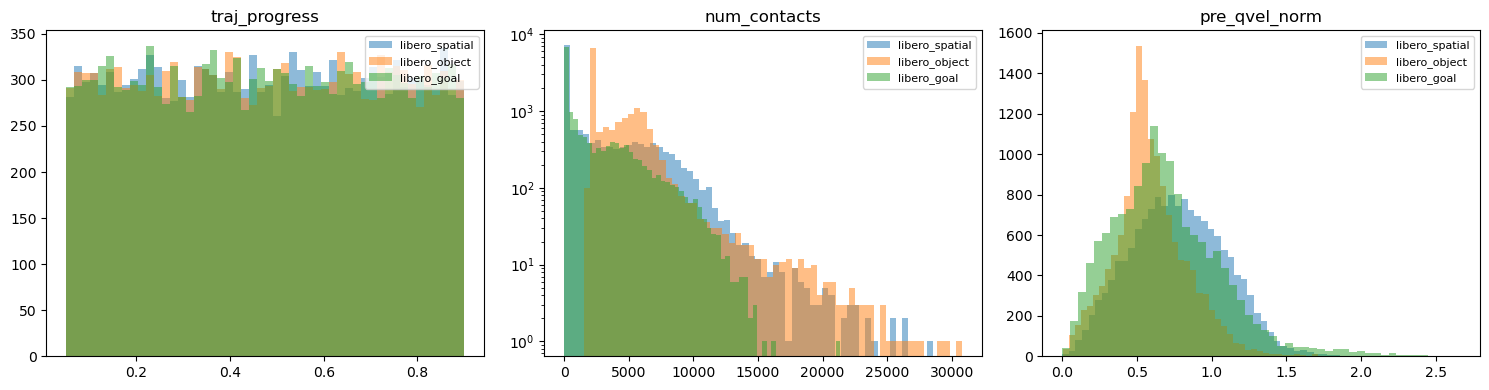

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, bins in [
    (axes[0], "traj_progress", 50),
    (axes[1], "num_contacts", 60),
    (axes[2], "pre_qvel_norm", 50),
]:
    for s in SPLITS:
        sub = manifest[manifest["split"] == s][col]
        ax.hist(sub, bins=bins, alpha=0.5, label=s)
    ax.set_title(col)
    ax.legend(fontsize=8)
axes[1].set_yscale("log")
plt.tight_layout()
plt.show()

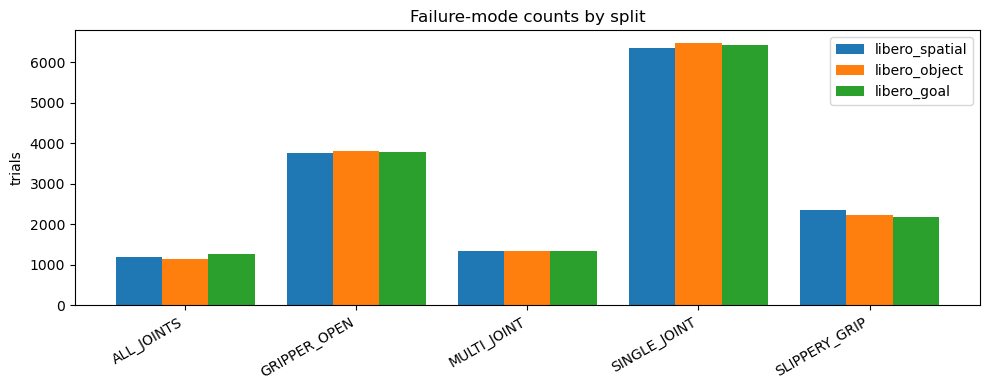

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))
for i, s in enumerate(SPLITS):
    counts = manifest[manifest["split"] == s]["failure_mode"].value_counts().sort_index()
    ax.bar(np.arange(len(counts)) + i * 0.27 - 0.27, counts.values, width=0.27, label=s)
ax.set_xticks(np.arange(len(counts)))
ax.set_xticklabels(counts.index, rotation=30, ha="right")
ax.set_ylabel("trials")
ax.set_title("Failure-mode counts by split")
ax.legend()
plt.tight_layout()
plt.show()

## 3a. Why LIBERO contact clouds look noisy — baseline contacts

Both pipelines (in-house v10 and LIBERO v1) record every contact above 1 N at every settle step for `post_failure_settle_steps=500`. So a single physical contact pair gets logged hundreds of times. **Aggregation is identical.**

The difference is the **scene baseline**:

- *In-house* scenes are sparse — pre-failure contacts are essentially fingers↔grasped-object plus, after release, object↔table.
- *LIBERO* scenes are cluttered — bowl-on-table, plate-on-table, drawer-against-frame, gripper-holding-bowl, pedestal-on-floor — *all standing contacts before any failure*. They persist through the 500 settle steps, so the raw cloud is dominated by baseline noise (median 2,019 contacts/trial vs ~hundreds in v10).

The npz stores raw `(geom1, geom2)` pairs by design. The diagnostic below filters them at load time using **entity-level baseline filtering** (port of the logic in `notebooks/inspect_libero.ipynb`). You should use this filter — or build density targets that account for it — before training.

In [10]:
import mujoco
from planner.experiments.libero.adapter import load_demo, materialise_mjcf
from planner.experiments.libero.naming import resolve_model_handles


def _kinematic_step(model, data, h, arm_q, finger_q):
    for adr, q in zip(h.arm_qpos_adrs, arm_q):
        data.qpos[adr] = q
    if len(h.finger_qpos_adrs) == 2:
        for adr, q in zip(h.finger_qpos_adrs, finger_q):
            data.qpos[adr] = q
    for adr in h.arm_dof_adrs:
        data.qvel[adr] = 0.0
    for adr in h.finger_dof_adrs:
        data.qvel[adr] = 0.0
    mujoco.mj_forward(model, data)


def build_entity_map(model, robot_prefixes=("robot0_", "gripper0_", "mount0_")):
    """Map every geom -> its top-level scene entity (robot collapsed to one id)."""
    ent = np.zeros(model.ngeom, dtype=np.int64)
    for gid in range(model.ngeom):
        bid = int(model.geom_bodyid[gid])
        bname = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, bid) or ""
        if bname.startswith(robot_prefixes):
            ent[gid] = -1  # robot
            continue
        cur = bid
        while cur > 0 and int(model.body_parentid[cur]) > 0:
            cur = int(model.body_parentid[cur])
        ent[gid] = cur
    return ent


def entity_label(model, eid):
    if eid == -1:
        return "robot"
    if eid == 0:
        return "world"
    return mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, int(eid)) or f"body_{eid}"


def entity_pair(ent_map, g1, g2):
    a, b = int(ent_map[g1]), int(ent_map[g2])
    return (a, b) if a <= b else (b, a)


_KP = np.array([600., 600., 600., 600., 300., 120., 120.])
_KD = 2 * np.sqrt(_KP)


def _apply_resistance(model, data, h, target_qpos):
    mujoco.mj_forward(model, data)
    for i, jid in enumerate(h.arm_joint_ids):
        aid = h.arm_actuator_ids[i]
        if aid < 0:
            continue
        q = float(data.qpos[h.arm_qpos_adrs[i]])
        qd = float(data.qvel[h.arm_dof_adrs[i]])
        grav = float(data.qfrc_bias[h.arm_dof_adrs[i]])
        tau = grav + _KP[i] * (target_qpos[i] - q) - _KD[i] * qd
        lo, hi = model.actuator_ctrlrange[aid]
        data.ctrl[aid] = float(np.clip(tau, lo, hi))


def baseline_entity_pairs(model, demo, fail_idx, ent_map,
                          min_force=1.0, warmup_steps=200, sample_steps=300):
    """Replay kinematically up to fail_idx, then sample entity-pairs in contact."""
    data = mujoco.MjData(model)
    h = resolve_model_handles(model)
    if demo.init_state is not None:
        data.qpos[:model.nq] = demo.init_state[:model.nq]
        data.qvel[:model.nv] = demo.init_state[model.nq:model.nq + model.nv]
        mujoco.mj_forward(model, data)
    for t in range(fail_idx + 1):
        _kinematic_step(model, data, h, demo.arm_qpos[t], demo.finger_qpos[t])
    target = demo.arm_qpos[fail_idx].astype(np.float64).copy()
    for _ in range(warmup_steps):
        _apply_resistance(model, data, h, target)
        mujoco.mj_step(model, data)
    pairs = set()
    f = np.zeros(6)
    for _ in range(sample_steps):
        _apply_resistance(model, data, h, target)
        mujoco.mj_step(model, data)
        for i in range(data.ncon):
            c = data.contact[i]
            mujoco.mj_contactForce(model, data, i, f)
            if np.linalg.norm(f[:3]) >= min_force:
                pairs.add(entity_pair(ent_map, c.geom1, c.geom2))
    # Self-entity pairs (cabinet-internal, robot-internal) always count as baseline.
    for e in set(int(x) for x in ent_map):
        pairs.add((e, e))
    return pairs


def hdf5_for_row(row):
    """Source HDF5 path for a manifest row."""
    return f"datasets/libero/raw/{row['split']}/{row['task']}_demo.hdf5"


print("helpers ready")

helpers ready


trial: libero_spatial / pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate / demo_0
  failure_mode: SINGLE_JOINT  joints='joint2'
  T=98  fail_idx=17  (10 scene entities)


  baseline entity-pairs: 16
  raw=831  baseline=0 (0.0%)  induced=831


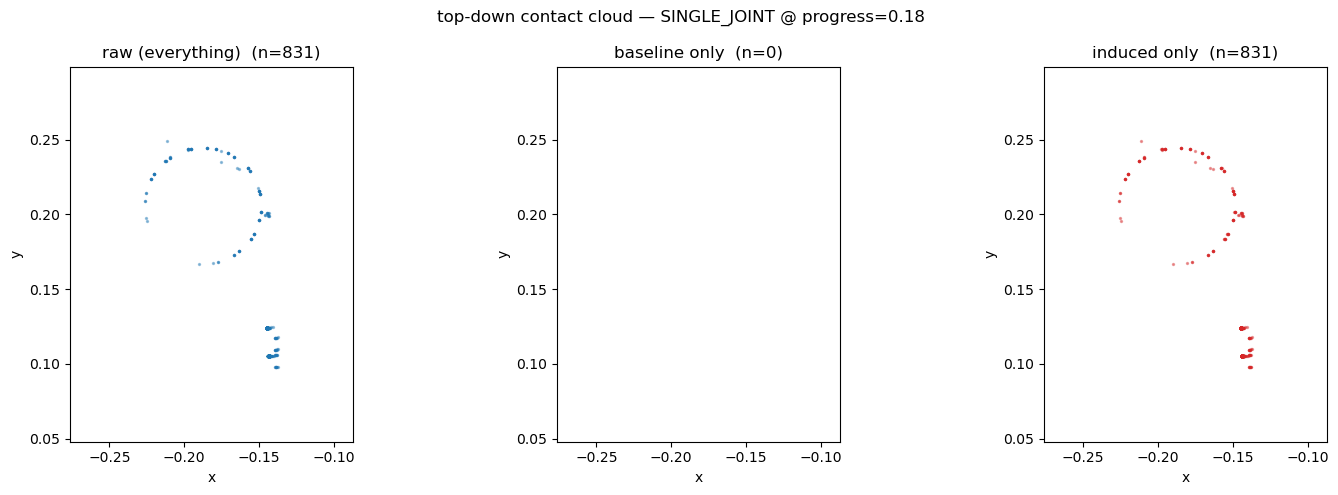

In [11]:
# Diagnostic: raw vs baseline-filtered contact cloud for one trial.
# Pick the first manifest row with at least some contacts (a row with
# num_contacts==0 makes the boolean filter degenerate).
DIAG_TRIAL_IDX = int(manifest.index[manifest["num_contacts"] > 0][0])

row = manifest.iloc[DIAG_TRIAL_IDX]
npz = dict(np.load(os.path.join(ROOT, row["split"], row["npz_file"]), allow_pickle=True))

demo = load_demo(hdf5_for_row(row), row["demo_key"])
xml_path = materialise_mjcf(demo.model_xml)
model = mujoco.MjModel.from_xml_path(xml_path)
T = demo.arm_qpos.shape[0]
fail_idx = max(1, min(int(float(row["traj_progress"]) * (T - 1)), T - 1))

ent_map = build_entity_map(model)
print(f"trial: {row['split']} / {row['task']} / {row['demo_key']}")
print(f"  failure_mode: {row['failure_mode']}  joints={row['failure_joints']!r}")
print(f"  T={T}  fail_idx={fail_idx}  ({len(set(int(e) for e in ent_map))} scene entities)")

baseline = baseline_entity_pairs(model, demo, fail_idx, ent_map)
print(f"  baseline entity-pairs: {len(baseline)}")

# Split stored contacts into baseline vs induced via entity-pair lookup.
geom_pairs = npz["contact_geom_pairs"]
positions = npz["contact_positions"]
forces = npz["contact_forces"]
is_baseline = np.array(
    [entity_pair(ent_map, int(g1), int(g2)) in baseline for g1, g2 in geom_pairs],
    dtype=bool,
)
n_raw = len(positions)
n_base = int(is_baseline.sum())
n_ind = n_raw - n_base
print(f"  raw={n_raw}  baseline={n_base} ({100*n_base/max(n_raw,1):.1f}%)  induced={n_ind}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
clouds = [
    ("raw (everything)", positions, "tab:blue"),
    ("baseline only",    positions[is_baseline], "tab:gray"),
    ("induced only",     positions[~is_baseline], "tab:red"),
]
# Use a common axis for direct visual comparison.
all_xy = positions[:, :2]
xlim = (all_xy[:, 0].min() - 0.05, all_xy[:, 0].max() + 0.05)
ylim = (all_xy[:, 1].min() - 0.05, all_xy[:, 1].max() + 0.05)
for ax, (label, pts, color) in zip(axes, clouds):
    if len(pts):
        ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.4, c=color)
    ax.set_title(f"{label}  (n={len(pts)})")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal")
plt.suptitle(f"top-down contact cloud — {row['failure_mode']} @ progress={row['traj_progress']:.2f}")
plt.tight_layout()
plt.show()

## 4. Single-trial viewer

Set `TRIAL_IDX` to any row index from `manifest` to inspect that trial's npz contents.

In [12]:
TRIAL_IDX = 0  # pick anything in [0, 45000)

row = manifest.iloc[TRIAL_IDX]
npz_path = os.path.join(ROOT, row["split"], row["npz_file"])
data = dict(np.load(npz_path, allow_pickle=True))

print(f"Path:           {npz_path}")
print(f"Split / task:   {row['split']} / {row['task']}")
print(f"Demo / seed / bin: {row['demo_key']} / {row['seed']} / {row['bin_idx']}")
print(f"traj_progress:  {row['traj_progress']}")
print(f"failure_mode:   {row['failure_mode']}  joints={row['failure_joints']!r}")
print(f"num_contacts:   {row['num_contacts']}")
print()
print("NPZ keys:")
for k in sorted(data):
    v = data[k]
    print(f"  {k:28s} shape={str(v.shape):20s} dtype={v.dtype}")

Path:           datasets/libero/v1/libero_spatial/exp_libero_spatial_pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_demo_0_s0_b0.npz
Split / task:   libero_spatial / pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate
Demo / seed / bin: demo_0 / 985902766 / 0
traj_progress:  0.0899
failure_mode:   GRIPPER_OPEN  joints=nan
num_contacts:   0

NPZ keys:
  contact_failure_id           shape=(0,)                 dtype=int32
  contact_forces               shape=(0, 6)               dtype=float32
  contact_geom_pairs           shape=(0, 2)               dtype=int32
  contact_positions            shape=(0, 3)               dtype=float32
  failure_modes                shape=(1,)                 dtype=<U12
  failure_probs                shape=(1,)                 dtype=float32
  impacted_geom_ids            shape=(0,)                 dtype=int32
  post_rgb                     shape=(480, 640, 3)        dtype=uint8
  pre_depth    

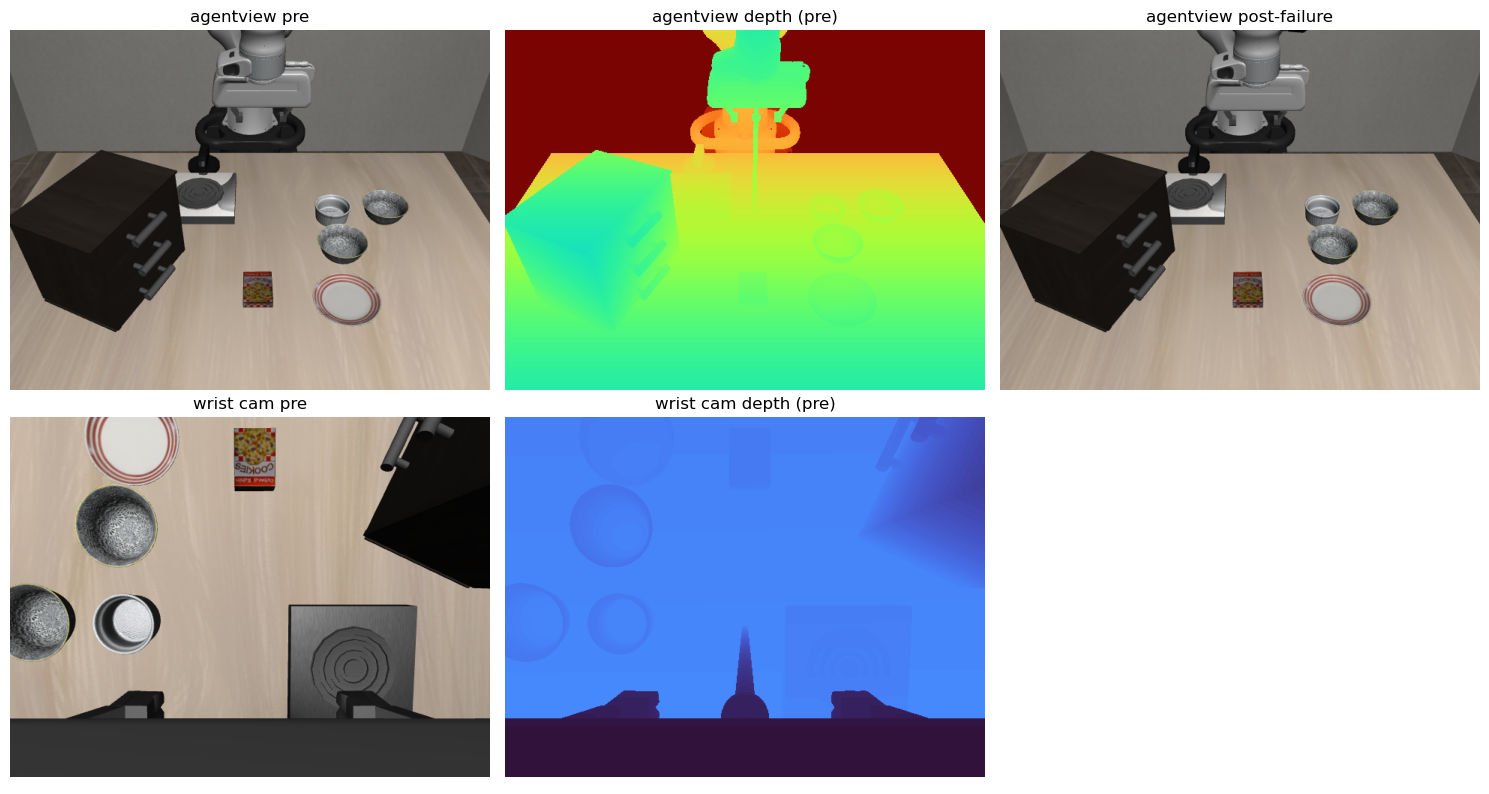

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
panels = [
    ("pre_rgb", "agentview pre"),
    ("pre_depth", "agentview depth (pre)"),
    ("post_rgb", "agentview post-failure"),
    ("robot0_eye_in_hand_rgb", "wrist cam pre"),
    ("robot0_eye_in_hand_depth", "wrist cam depth (pre)"),
]
for ax, (key, title) in zip(axes, panels):
    if key not in data:
        ax.set_title(f"missing: {key}")
        ax.axis("off")
        continue
    img = data[key]
    if "depth" in key:
        ax.imshow(img, cmap="turbo", vmin=0.05, vmax=2.0)
    else:
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

In [14]:
print("pre_qpos        :", np.round(data["pre_qpos"], 4))
print("pre_qvel        :", np.round(data["pre_qvel"], 4))
print("pre_target_qpos :", np.round(data["pre_target_qpos"], 4))
print("pre_ee_pos      :", np.round(data["pre_ee_pos"], 4))
print("pre_gripper_ctrl:", float(data["pre_gripper_ctrl"][0]))
print()
print("target − qpos  :", np.round(data["pre_target_qpos"] - data["pre_qpos"], 4))

pre_qpos        : [ 0.0163 -0.0902  0.0318 -2.3361  0.0068  2.1793  0.8301]
pre_qvel        : [0.0508 0.5648 0.2289 0.6068 0.0392 0.0169 0.2502]
pre_target_qpos : [ 0.0189 -0.0606  0.0436 -2.3045  0.0075  2.1811  0.8438]
pre_ee_pos      : [-0.1813  0.0236  1.1826]
pre_gripper_ctrl: 9.991569335474071e-05

target − qpos  : [0.0026 0.0296 0.0118 0.0317 0.0007 0.0018 0.0136]


In [15]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pos = data["contact_positions"]
forces = data["contact_forces"]
fmag = np.linalg.norm(forces[:, :3], axis=1) if len(forces) else np.array([])

if len(pos) == 0:
    print("No contacts.")
else:
    fig = plt.figure(figsize=(12, 5))
    ax3 = fig.add_subplot(1, 2, 1, projection="3d")
    sc = ax3.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=fmag, s=2, alpha=0.4, cmap="viridis")
    ax3.set_xlabel("x"); ax3.set_ylabel("y"); ax3.set_zlabel("z")
    ax3.set_title(f"contact cloud (n={len(pos)})")
    plt.colorbar(sc, ax=ax3, label="|F|")

    ax2 = fig.add_subplot(1, 2, 2)
    ax2.scatter(pos[:, 0], pos[:, 1], c=fmag, s=2, alpha=0.4, cmap="viridis")
    ax2.set_xlabel("x"); ax2.set_ylabel("y")
    ax2.set_title("top-down (x,y)")
    ax2.set_aspect("equal")
    plt.tight_layout()
    plt.show()
    print(f"force magnitude: median={np.median(fmag):.2f} N, max={fmag.max():.2f} N")
    pair_counts = Counter(map(tuple, data["contact_geom_pairs"]))
    print(f"unique geom pairs: {len(pair_counts)}")
    print("top 8 pairs:")
    for pair, n in pair_counts.most_common(8):
        print(f"  {pair}: {n}")

No contacts.


## 5. RGB grid — many trials at once

Random sample so you can spot diversity / outliers visually.

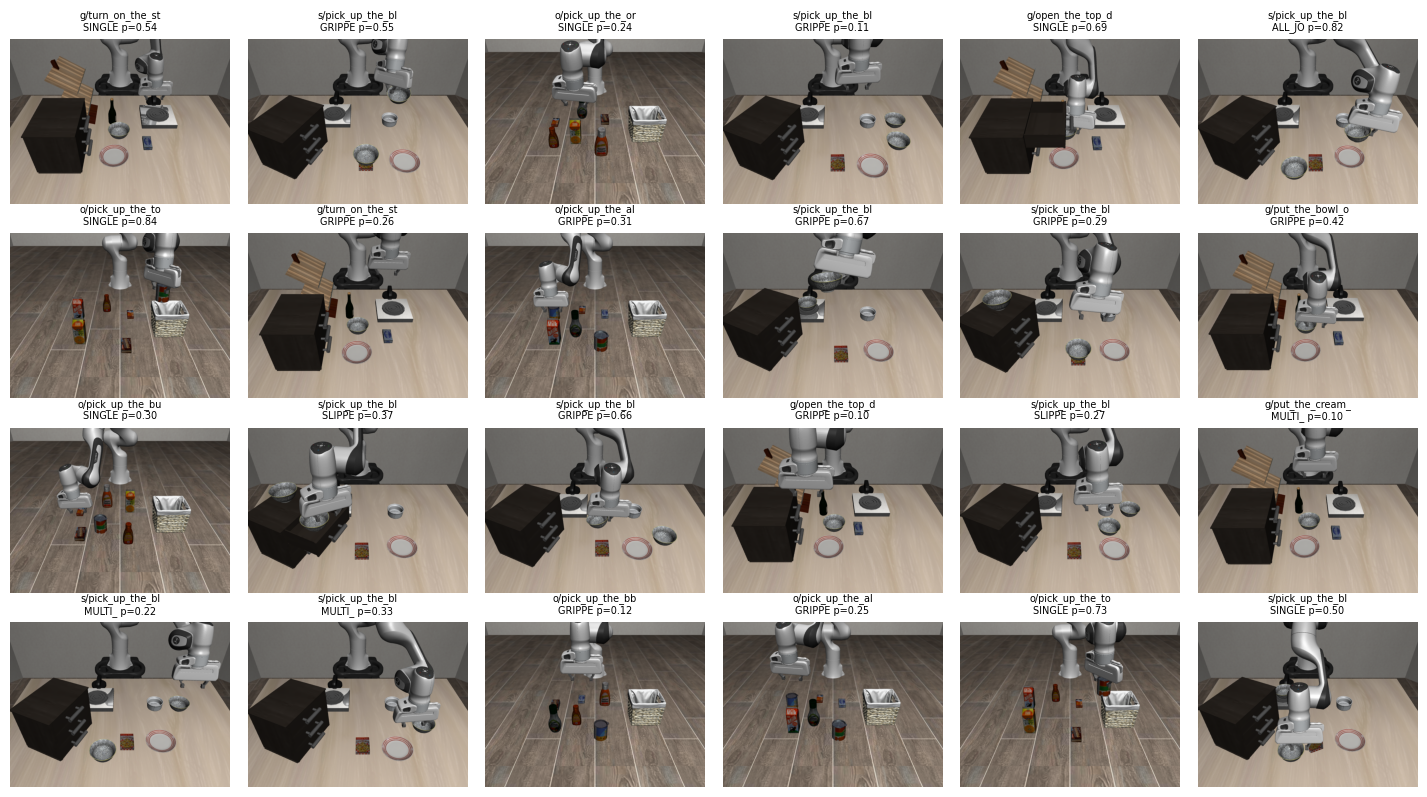

In [16]:
GRID_N = 24
GRID_COLS = 6
FILTER = {}  # e.g. {"split": "libero_goal", "failure_mode": "SINGLE_JOINT"}

pool = manifest
for k, v in FILTER.items():
    pool = pool[pool[k] == v]
sample = pool.sample(min(GRID_N, len(pool)), random_state=0)

rows = (len(sample) + GRID_COLS - 1) // GRID_COLS
fig, axes = plt.subplots(rows, GRID_COLS, figsize=(GRID_COLS * 2.4, rows * 2.0))
axes = np.atleast_2d(axes).flatten()
for ax, (_, r) in zip(axes, sample.iterrows()):
    p = os.path.join(ROOT, r["split"], r["npz_file"])
    with np.load(p, allow_pickle=True) as z:
        ax.imshow(z["pre_rgb"])
    ax.set_title(f"{r['split'][7]}/{r['task'][:14]}\n{r['failure_mode'][:6]} p={r['traj_progress']:.2f}", fontsize=7)
    ax.axis("off")
for ax in axes[len(sample):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Demo timeline — all samples for one demo

For a chosen `(SPLIT, TASK, DEMO)` we expect 30 samples (3 seeds × 10 progress bins). This section orders them by `traj_progress` and shows:

- **Timeline** — where each sample's failure point lies on the demo's `[0, 1]` progress axis, coloured by `failure_mode`.
- **Thumbnail grid** — the 30 `pre_rgb` images in progress order.
- **State table** — joint / EE state per sample.

In [17]:
import h5py

SPLIT = "libero_spatial"
TASK = sorted(manifest[manifest["split"] == SPLIT]["task"].unique())[0]
DEMO = "demo_0"

demo_rows = manifest[
    (manifest["split"] == SPLIT)
    & (manifest["task"] == TASK)
    & (manifest["demo_key"] == DEMO)
].sort_values("traj_progress").reset_index(drop=True)

hdf5_path = f"datasets/libero/raw/{SPLIT}/{TASK}_demo.hdf5"
try:
    with h5py.File(hdf5_path, "r") as f:
        demo_T = int(f[f"data/{DEMO}/obs/joint_states"].shape[0])
except (OSError, KeyError):
    demo_T = None

print(f"split   : {SPLIT}")
print(f"task    : {TASK}")
print(f"demo    : {DEMO}")
print(f"hdf5    : {hdf5_path}")
print(f"demo T  : {demo_T} steps")
print(f"samples : {len(demo_rows)} (expected 30 = 3 seeds × 10 bins)")
demo_rows[["bin_idx", "seed", "traj_progress", "failure_mode", "failure_joints", "num_contacts"]].head(10)

split   : libero_spatial
task    : pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate
demo    : demo_0
hdf5    : datasets/libero/raw/libero_spatial/pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_demo.hdf5
demo T  : 98 steps
samples : 30 (expected 30 = 3 seeds × 10 bins)


,bin_idx,seed,traj_progress,failure_mode,failure_joints,num_contacts
0,0,938978701,0.0596,GRIPPER_OPEN,NaN,0
1,0,985902766,0.0899,GRIPPER_OPEN,NaN,0
2,0,605868472,0.0955,SINGLE_JOINT,joint2,401
3,1,424233390,0.1625,SINGLE_JOINT,joint4,0
4,1,2019759331,0.1642,SINGLE_JOINT,joint6,0
5,1,2126267328,0.1772,SINGLE_JOINT,joint2,831
6,2,1536157591,0.2484,MULTI_JOINT,"joint2,joint4",853
7,2,1976801033,0.2871,SINGLE_JOINT,joint4,804
8,2,645016585,0.3007,SINGLE_JOINT,joint6,0
9,3,1057609893,0.3385,SINGLE_JOINT,joint2,9478


### 6a. Timeline plot — failure positions on the demo

Each marker is one sample. Vertical position spreads samples that share a `traj_progress` (multiple seeds in the same bin) so they don't overlap. Colour = failure mode. Demo bookends `0.0` and `1.0` shown as dashed lines.

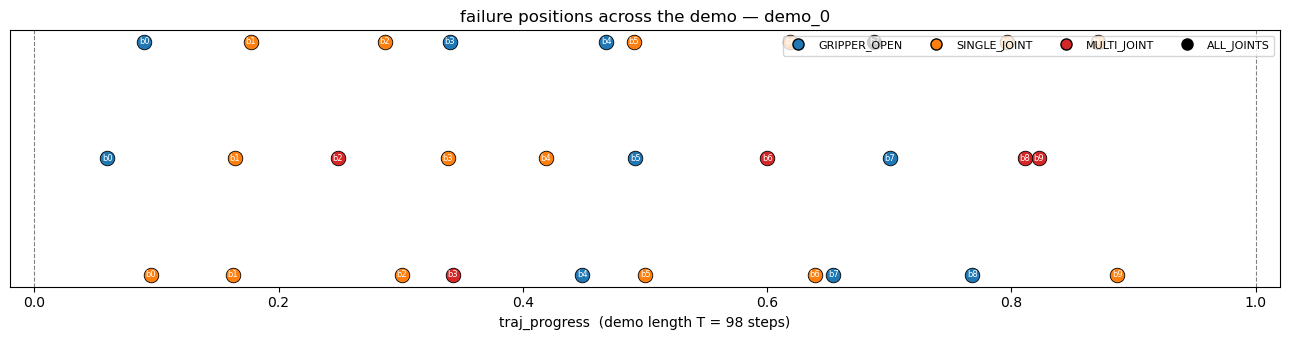

In [18]:
FMODE_COLOURS = {
    "GRIPPER_OPEN":  "tab:blue",
    "SLIPPERY_GRIP": "tab:cyan",
    "SINGLE_JOINT":  "tab:orange",
    "MULTI_JOINT":   "tab:red",
    "ALL_JOINTS":    "black",
}

# Group samples by bin so multiple seeds in the same bin can be drawn at
# different y-offsets (otherwise they'd land on top of each other).
fig, ax = plt.subplots(figsize=(13, 3.5))
for bin_idx, group in demo_rows.groupby("bin_idx"):
    g = group.sort_values("seed").reset_index(drop=True)
    for k, (_, r) in enumerate(g.iterrows()):
        y = (k - (len(g) - 1) / 2) * 0.25  # spread vertically per bin
        c = FMODE_COLOURS.get(r["failure_mode"], "gray")
        ax.scatter(r["traj_progress"], y, s=110, c=c, edgecolor="black", linewidth=0.6,
                   zorder=3)
        ax.annotate(f"b{r['bin_idx']}", (r["traj_progress"], y),
                    fontsize=6, ha="center", va="center", color="white", zorder=4)
ax.axvline(0.0, ls="--", c="grey", lw=0.8)
ax.axvline(1.0, ls="--", c="grey", lw=0.8)
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel(f"traj_progress  (demo length T = {demo_T} steps)")
ax.set_yticks([])
ax.set_title(f"failure positions across the demo — {DEMO}")
# Legend
from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker="o", linestyle="", markersize=8,
                  markerfacecolor=c, markeredgecolor="black", label=m)
           for m, c in FMODE_COLOURS.items()
           if m in set(demo_rows["failure_mode"])]
ax.legend(handles=handles, loc="upper right", fontsize=8, ncol=len(handles))
plt.tight_layout()
plt.show()

### 6b. Thumbnail grid — `pre_rgb` for all 30 samples in progress order

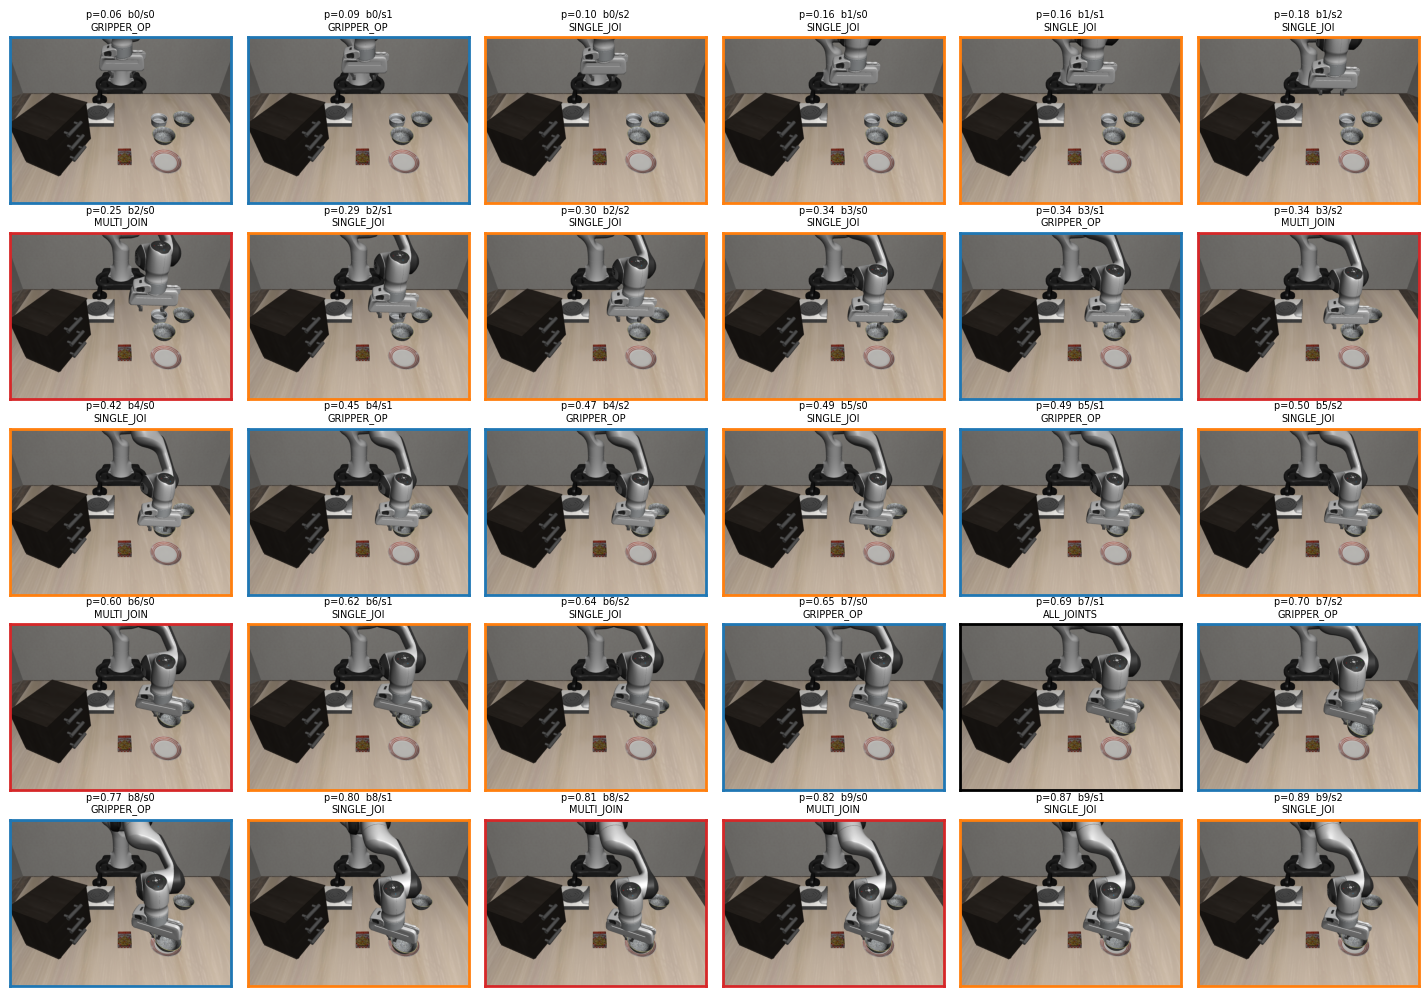

In [19]:
cols = 6
rows = (len(demo_rows) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.0))
axes = np.atleast_2d(axes).flatten()
for ax, (_, r) in zip(axes, demo_rows.iterrows()):
    p = os.path.join(ROOT, r["split"], r["npz_file"])
    with np.load(p, allow_pickle=True) as z:
        ax.imshow(z["pre_rgb"])
    seed_idx = list(demo_rows[demo_rows["bin_idx"] == r["bin_idx"]]["seed"]).index(r["seed"])
    border = FMODE_COLOURS.get(r["failure_mode"], "gray")
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(2.0)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"p={r['traj_progress']:.2f}  b{r['bin_idx']}/s{seed_idx}\n{r['failure_mode'][:10]}",
                 fontsize=7)
for ax in axes[len(demo_rows):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 6c. State table — qpos / target / EE per sample, in progress order

In [20]:
records = []
for _, r in demo_rows.iterrows():
    p = os.path.join(ROOT, r["split"], r["npz_file"])
    with np.load(p, allow_pickle=True) as z:
        records.append({
            "bin": r["bin_idx"],
            "seed": int(r["seed"]),
            "progress": round(float(r["traj_progress"]), 3),
            "step": int(round(float(r["traj_progress"]) * (demo_T - 1))) if demo_T else None,
            "ee_x": round(float(z["pre_ee_pos"][0]), 3),
            "ee_y": round(float(z["pre_ee_pos"][1]), 3),
            "ee_z": round(float(z["pre_ee_pos"][2]), 3),
            "|q-target|": round(float(np.linalg.norm(z["pre_target_qpos"] - z["pre_qpos"])), 4),
            "grip": round(float(z["pre_gripper_ctrl"][0]), 3),
            "failure": r["failure_mode"],
            "joints": r["failure_joints"],
            "n_contacts": r["num_contacts"],
        })
pd.DataFrame(records)

,bin,seed,progress,step,ee_x,ee_y,ee_z,|q-target|,grip,failure,joints,n_contacts
0,0,938978701,0.060,6,-0.205,0.003,1.182,0.0295,0.000,GRIPPER_OPEN,NaN,0
1,0,985902766,0.090,9,-0.181,0.024,1.183,0.0471,0.000,GRIPPER_OPEN,NaN,0
2,0,605868472,0.096,9,-0.171,0.031,1.182,0.0494,0.000,SINGLE_JOINT,joint2,401
3,1,424233390,0.163,16,-0.108,0.080,1.169,0.0584,0.000,SINGLE_JOINT,joint4,0
4,1,2019759331,0.164,16,-0.108,0.080,1.169,0.0584,0.000,SINGLE_JOINT,joint6,0
5,1,2126267328,0.177,17,-0.088,0.096,1.158,0.0587,0.000,SINGLE_JOINT,joint2,831
6,2,1536157591,0.248,24,-0.036,0.132,1.088,0.0322,0.000,MULTI_JOINT,"joint2,joint4",853
7,2,1976801033,0.287,28,-0.030,0.139,1.055,0.0329,0.000,SINGLE_JOINT,joint4,804
8,2,645016585,0.301,29,-0.031,0.147,1.033,0.0384,0.000,SINGLE_JOINT,joint6,0
9,3,1057609893,0.339,33,-0.034,0.161,0.997,0.0478,0.000,SINGLE_JOINT,joint2,9478


### 6d. Per-sample contact overlay on `pre_rgb`

Same 5×6 grid as §6b, but each sample's failure-induced contacts (after the §3a entity-pair filter) are projected onto its `pre_rgb` via `ContactProjector(camera="agentview")`. Baseline contacts are drawn faint grey for context; induced contacts are red, sized by force magnitude. This is the per-config view — one cloud per (demo, seed, bin).

The baseline is computed once for this demo at its median `fail_idx` (the standing-contact entity set is essentially constant across a demo), so the heavy mujoco replay only happens once per demo.

shared baseline @ progress=0.480 (fail_idx=46/98): 16 entity-pairs


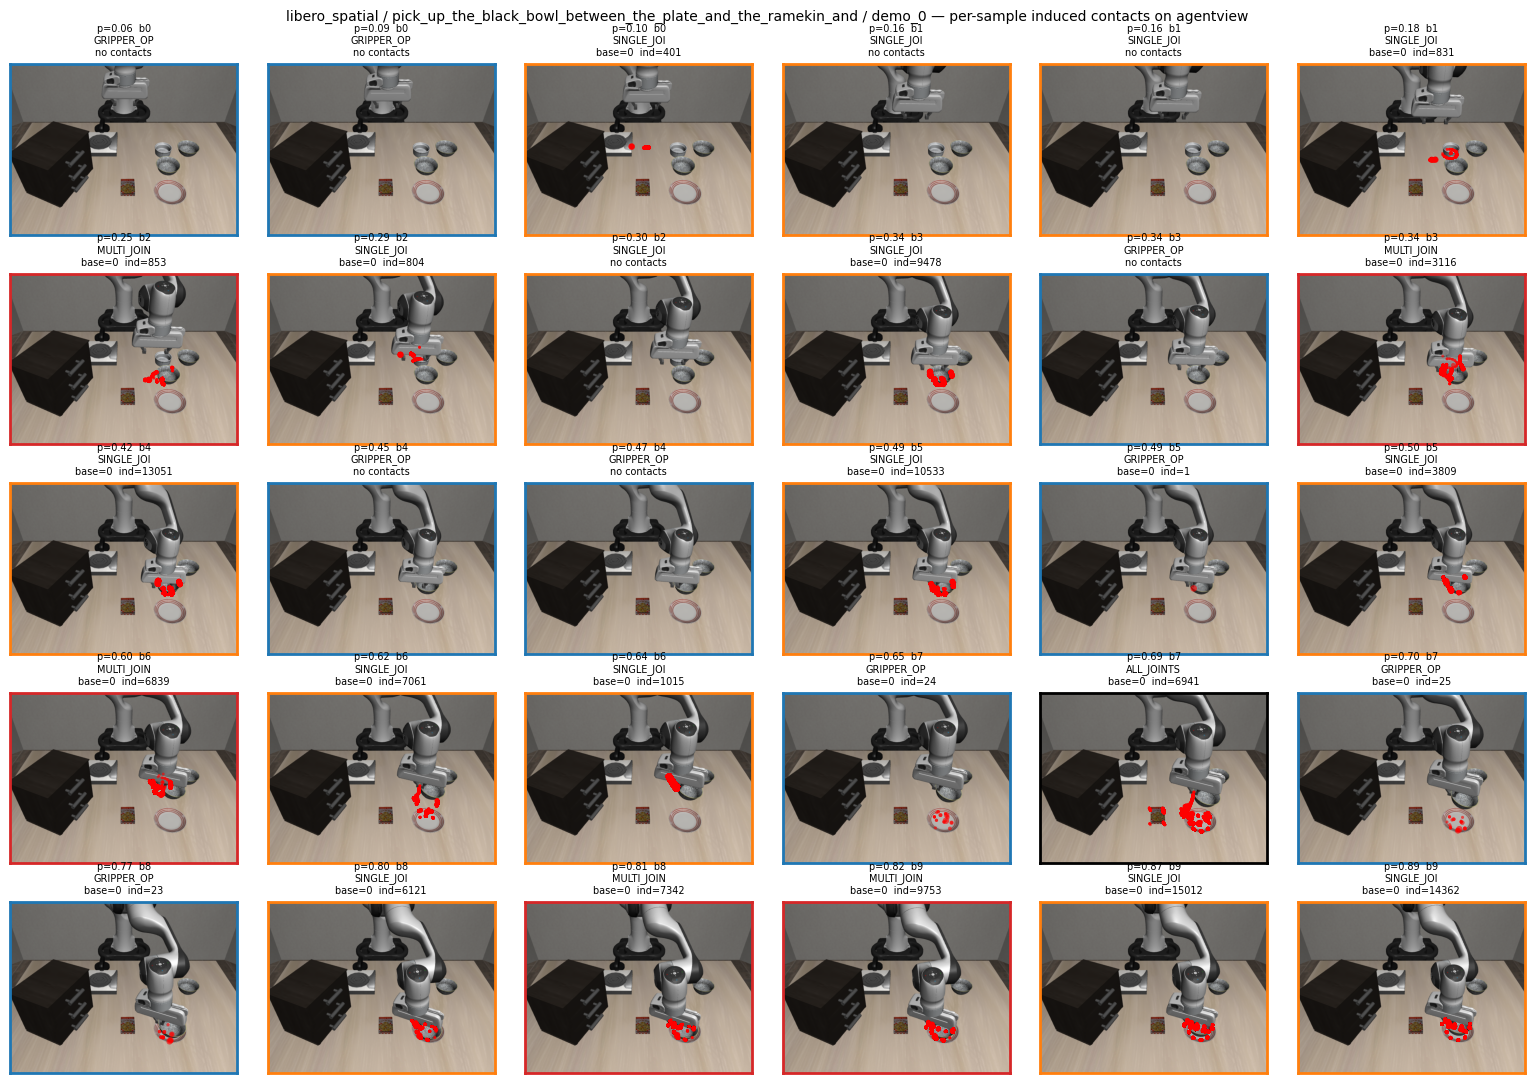


induced contacts per sample: min=0 median=842 max=15012  (8/30 samples had 0 induced)


In [21]:
from planner.experiments.data_capture import ContactProjector

# One shared baseline + projector for this demo.
demo_for_overlay = load_demo(hdf5_for_row(demo_rows.iloc[0]), DEMO)
xml_path = materialise_mjcf(demo_for_overlay.model_xml)
demo_model = mujoco.MjModel.from_xml_path(xml_path)
demo_T_local = demo_for_overlay.arm_qpos.shape[0]
median_progress = float(demo_rows["traj_progress"].median())
median_fail_idx = max(1, min(int(median_progress * (demo_T_local - 1)), demo_T_local - 1))

demo_ent_map = build_entity_map(demo_model)
demo_baseline = baseline_entity_pairs(demo_model, demo_for_overlay, median_fail_idx, demo_ent_map)
print(f"shared baseline @ progress={median_progress:.3f} (fail_idx={median_fail_idx}/{demo_T_local}): "
      f"{len(demo_baseline)} entity-pairs")

# Use the npz's image dimensions for the projector. agentview is fixed in world.
with np.load(os.path.join(ROOT, demo_rows.iloc[0]["split"], demo_rows.iloc[0]["npz_file"]),
             allow_pickle=True) as z0:
    H, W = z0["pre_rgb"].shape[:2]
proj = ContactProjector(demo_model, width=W, height=H, camera_name="agentview")
proj.validate()

cols = 6
rows = (len(demo_rows) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.6, rows * 2.2))
axes = np.atleast_2d(axes).flatten()

per_sample_counts = []
for ax, (_, r) in zip(axes, demo_rows.iterrows()):
    p = os.path.join(ROOT, r["split"], r["npz_file"])
    with np.load(p, allow_pickle=True) as z:
        pre_rgb = z["pre_rgb"]
        pairs = z["contact_geom_pairs"]
        pts = z["contact_positions"]
        forces = z["contact_forces"]

    ax.imshow(pre_rgb)
    border = FMODE_COLOURS.get(r["failure_mode"], "gray")
    for spine in ax.spines.values():
        spine.set_edgecolor(border); spine.set_linewidth(2.0)
    ax.set_xticks([]); ax.set_yticks([])

    if len(pts) == 0:
        ax.set_title(f"p={r['traj_progress']:.2f}  b{r['bin_idx']}\n{r['failure_mode'][:10]}\nno contacts",
                     fontsize=7)
        per_sample_counts.append((0, 0))
        continue

    is_base = np.array(
        [entity_pair(demo_ent_map, int(g1), int(g2)) in demo_baseline for g1, g2 in pairs]
    )
    base_pts = pts[is_base]
    ind_pts = pts[~is_base]
    ind_f = np.linalg.norm(forces[~is_base, :3], axis=1) if len(ind_pts) else np.array([])

    if len(base_pts):
        bx, bd = proj.project(base_pts)
        bm = proj.in_frame(bx, bd)
        ax.scatter(bx[bm, 0], bx[bm, 1], c="lightgrey", s=1, alpha=0.25)
    if len(ind_pts):
        ix, idp = proj.project(ind_pts)
        im = proj.in_frame(ix, idp)
        if im.any():
            sizes = 4 + 18 * (ind_f[im] / max(ind_f[im].max(), 1.0))
            ax.scatter(ix[im, 0], ix[im, 1], c="red", s=sizes, alpha=0.6, edgecolor="none")
    per_sample_counts.append((len(base_pts), len(ind_pts)))
    ax.set_title(
        f"p={r['traj_progress']:.2f}  b{r['bin_idx']}\n{r['failure_mode'][:10]}\n"
        f"base={len(base_pts)}  ind={len(ind_pts)}",
        fontsize=7,
    )

for ax in axes[len(demo_rows):]:
    ax.axis("off")

plt.suptitle(
    f"{SPLIT} / {TASK[:60]} / {DEMO} — per-sample induced contacts on agentview",
    fontsize=10,
)
plt.tight_layout()
plt.show()

induced_counts = [c[1] for c in per_sample_counts]
print(f"\ninduced contacts per sample: min={min(induced_counts)} median={int(np.median(induced_counts))} "
      f"max={max(induced_counts)}  ({sum(c == 0 for c in induced_counts)}/{len(induced_counts)} samples had 0 induced)")

### 6e. Counterfactual failures — same initial state, different failure mode

§6d shows the *one* failure mode that was actually sampled at each (seed, bin). Here we re-run the same demo at the same `fail_idx` under **every** failure mode in the menu. Each row = one chosen initial state (a seed × bin from §6d), each column = a failure mode. Cells show `post_rgb` with induced contacts (entity-pair filter) overlaid in red.

Set `N_STATES` to control how many initial states to play out (default 5 — keeps runtime under ~2 min). Set to `len(demo_rows)` to play out all 30.

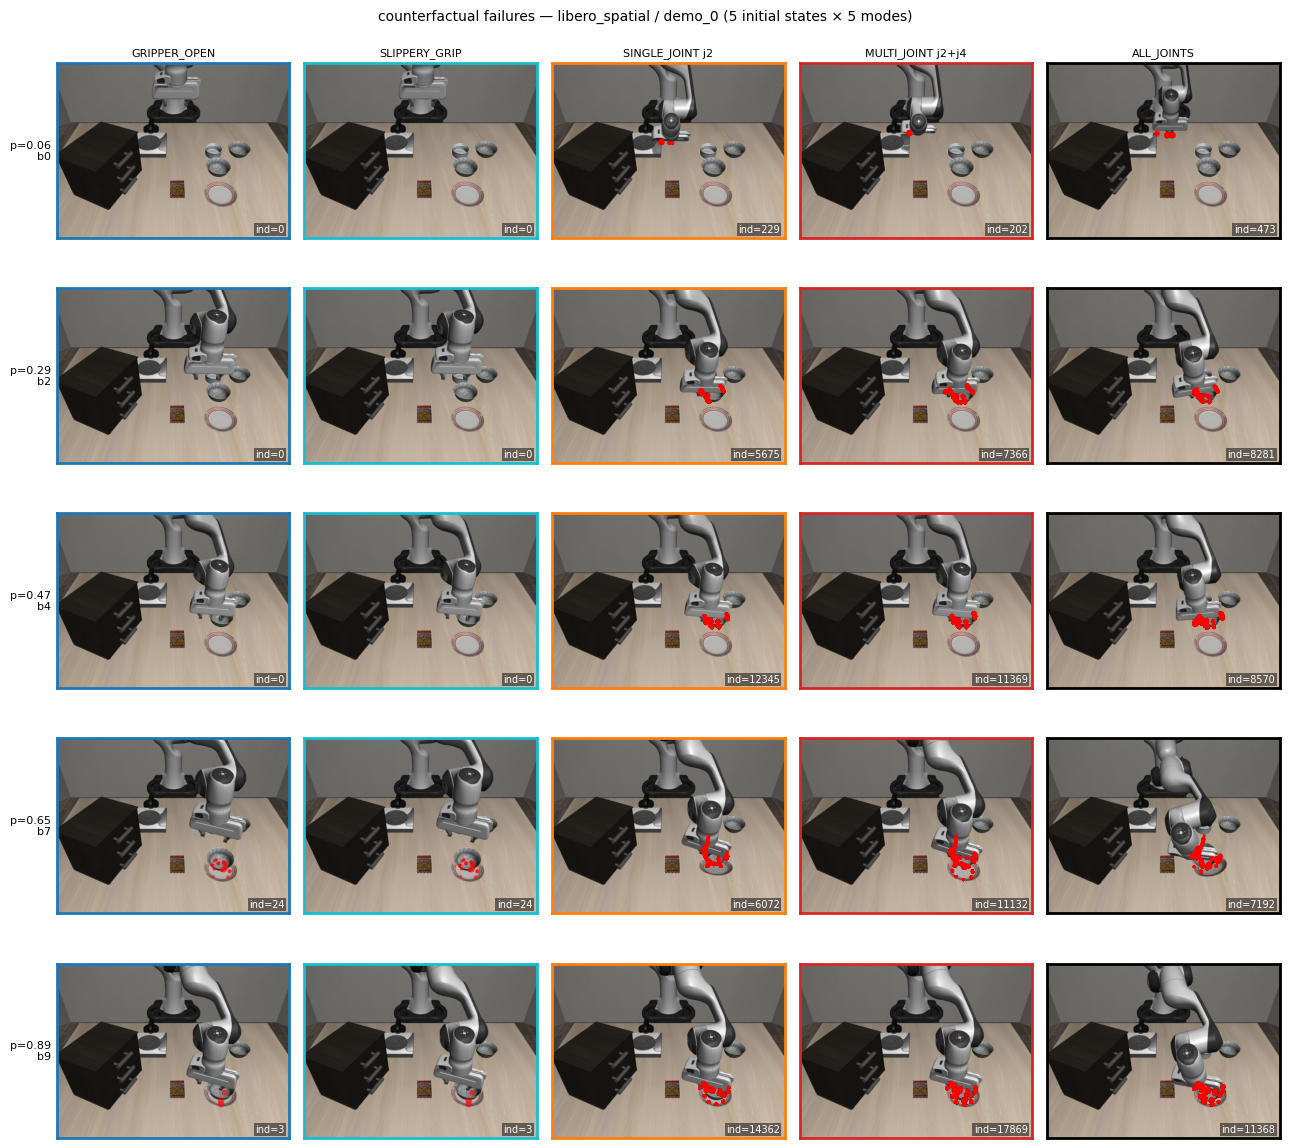

In [22]:
from planner.experiments.config import FailureConfig, FailureMode
from planner.experiments.libero.runner import LiberoRunner, LiberoTrialConfig

# Pick which initial states to play out. Evenly spaced across the demo.
N_STATES = 5
state_idxs = np.linspace(0, len(demo_rows) - 1, N_STATES, dtype=int).tolist()

# Failure modes to sweep. SINGLE_JOINT/MULTI_JOINT need a joint spec; pick
# representative ones that load gravity (j2 shoulder, j2+j4).
SWEEP = [
    ("GRIPPER_OPEN",      FailureConfig(mode=FailureMode.GRIPPER_OPEN)),
    ("SLIPPERY_GRIP",     FailureConfig(mode=FailureMode.SLIPPERY_GRIP)),
    ("SINGLE_JOINT j2",   FailureConfig(mode=FailureMode.SINGLE_JOINT, joint_names=["joint2"])),
    ("MULTI_JOINT j2+j4", FailureConfig(mode=FailureMode.MULTI_JOINT, joint_names=["joint2", "joint4"])),
    ("ALL_JOINTS",        FailureConfig(mode=FailureMode.ALL_JOINTS)),
]

# Reuse the demo + projector + baseline from §6d.
sweep_demo = demo_for_overlay
sweep_T = sweep_demo.arm_qpos.shape[0]


def _contact_arrays(contact_points):
    """Convert List[ContactPoint] -> (positions, forces, geom_pairs) arrays."""
    if not contact_points:
        return (np.zeros((0, 3), np.float32),
                np.zeros((0, 6), np.float32),
                np.zeros((0, 2), np.int32))
    pos = np.stack([c.pos for c in contact_points]).astype(np.float32)
    forces = np.stack([c.force for c in contact_points]).astype(np.float32)
    pairs = np.array([(c.geom1, c.geom2) for c in contact_points], dtype=np.int32)
    return pos, forces, pairs


n_rows = len(state_idxs)
n_cols = len(SWEEP)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.6, n_rows * 2.4))
axes = np.atleast_2d(axes)

for ri, sidx in enumerate(state_idxs):
    base_row = demo_rows.iloc[sidx]
    progress = float(base_row["traj_progress"])
    for ci, (label, fc) in enumerate(SWEEP):
        ax = axes[ri, ci]
        cfg = LiberoTrialConfig(
            fail_progress=progress, failure_configs=[fc],
            seed=int(base_row["seed"]), resistance_mode="gravcomp_pd",
        )
        runner = LiberoRunner(sweep_demo, cfg)
        try:
            sample = runner.run()
        finally:
            runner.close()

        ax.imshow(sample.post_failure_rgb)

        pts, forces, pairs = _contact_arrays(sample.aggregate_contacts)
        n_ind = 0
        if len(pts):
            is_base = np.array(
                [entity_pair(demo_ent_map, int(g1), int(g2)) in demo_baseline
                 for g1, g2 in pairs],
                dtype=bool,
            )
            ind_pts = pts[~is_base]
            ind_f = (np.linalg.norm(forces[~is_base, :3], axis=1)
                      if len(ind_pts) else np.array([]))
            n_ind = int(len(ind_pts))
            if len(ind_pts):
                ix, idp = proj.project(ind_pts)
                im = proj.in_frame(ix, idp)
                if im.any():
                    sizes = 4 + 18 * (ind_f[im] / max(ind_f[im].max(), 1.0))
                    ax.scatter(ix[im, 0], ix[im, 1], c="red", s=sizes,
                               alpha=0.6, edgecolor="none")

        for spine in ax.spines.values():
            spine.set_edgecolor(FMODE_COLOURS.get(fc.mode.name, "gray"))
            spine.set_linewidth(2.0)
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(label, fontsize=8)
        if ci == 0:
            ax.set_ylabel(f"p={progress:.2f}\nb{base_row['bin_idx']}",
                          fontsize=8, rotation=0, ha="right", va="center")
        ax.text(0.98, 0.02, f"ind={n_ind}", transform=ax.transAxes,
                fontsize=7, ha="right", va="bottom", color="white",
                bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))

plt.suptitle(
    f"counterfactual failures — {SPLIT} / {DEMO} ({n_rows} initial states × {n_cols} modes)",
    fontsize=10,
)
plt.tight_layout()
plt.show()

### 6f. Verify saved npz contacts match a live re-run

Spot-check that the v1 dataset's stored contacts faithfully reflect what `LiberoRunner` produces today. Pick one manifest row, load its saved cloud, then re-run the same `(demo, seed, fail_progress, failure_mode, failure_joints)` config live and overlay both. They should overlap nearly perfectly (deterministic seed, same machine).

 bin       seed  progress         mode        joints  saved_n  live_n  Δn  saved_ind  live_ind  Δind  nn_mm match
   0  605868472     0.096 SINGLE_JOINT        joint2      401     401   0        401       401     0    0.0     ✅
   1 2126267328     0.177 SINGLE_JOINT        joint2      831     831   0        831       831     0    0.0     ✅
   2 1536157591     0.248  MULTI_JOINT joint2,joint4      853     853   0        853       853     0    0.0     ✅
   2 1976801033     0.287 SINGLE_JOINT        joint4      804     804   0        804       804     0    0.0     ✅
   3 1057609893     0.339 SINGLE_JOINT        joint2     9478    9478   0       9478      9478     0    0.0     ✅


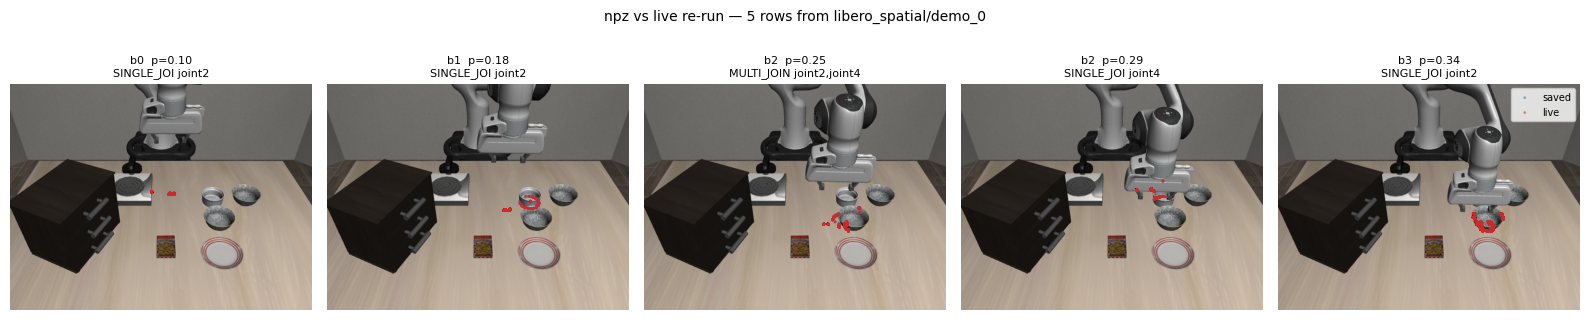

In [23]:
# Verify saved v1 npzs against live runner re-runs across several rows.
# Default: first N rows of this demo with non-degenerate contacts. Bump
# N_VERIFY to spot-check more.
N_VERIFY = 5

eligible = demo_rows[demo_rows["num_contacts"] > 0].reset_index(drop=True)
verify_rows = eligible.head(N_VERIFY)

def _induced(pts, pairs):
    if len(pts) == 0:
        return pts
    is_base = np.array(
        [entity_pair(demo_ent_map, int(g1), int(g2)) in demo_baseline for g1, g2 in pairs],
        dtype=bool,
    )
    return pts[~is_base]

def _mean_nn_dist(a, b, sample=500, rng=0):
    if len(a) == 0 or len(b) == 0:
        return float("nan")
    rng = np.random.default_rng(rng)
    if len(a) > sample:
        a = a[rng.choice(len(a), sample, replace=False)]
    diff = a[:, None, :] - b[None, :, :]
    return float(np.sqrt((diff ** 2).sum(-1)).min(axis=1).mean())

records = []
saved_clouds = []  # (saved_ind, live_ind, vrow) for plotting
for _, vrow in verify_rows.iterrows():
    saved = dict(np.load(os.path.join(ROOT, vrow["split"], vrow["npz_file"]),
                          allow_pickle=True))
    saved_pts = saved["contact_positions"]
    saved_pairs = saved["contact_geom_pairs"]

    joints_str = vrow["failure_joints"]
    joint_names = ([j for j in joints_str.split(",") if j]
                    if isinstance(joints_str, str) and joints_str else None)
    fc = FailureConfig(mode=FailureMode[vrow["failure_mode"]],
                        joint_names=joint_names)
    cfg = LiberoTrialConfig(
        fail_progress=float(vrow["traj_progress"]),
        failure_configs=[fc],
        seed=int(vrow["seed"]),
        resistance_mode="gravcomp_pd",
    )
    runner = LiberoRunner(sweep_demo, cfg)
    try:
        live_sample = runner.run()
    finally:
        runner.close()
    live_pts, live_forces, live_pairs = _contact_arrays(live_sample.aggregate_contacts)

    saved_ind = _induced(saved_pts, saved_pairs)
    live_ind = _induced(live_pts, live_pairs)
    nn_mm = _mean_nn_dist(saved_ind, live_ind) * 1000

    records.append({
        "bin": int(vrow["bin_idx"]),
        "seed": int(vrow["seed"]),
        "progress": round(float(vrow["traj_progress"]), 3),
        "mode": vrow["failure_mode"],
        "joints": vrow["failure_joints"] or "",
        "saved_n": len(saved_pts),
        "live_n": len(live_pts),
        "Δn": len(live_pts) - len(saved_pts),
        "saved_ind": len(saved_ind),
        "live_ind": len(live_ind),
        "Δind": len(live_ind) - len(saved_ind),
        "nn_mm": round(nn_mm, 3),
        "match": "✅" if (len(live_pts) == len(saved_pts) and nn_mm < 1.0) else "❌",
    })
    saved_clouds.append((saved_ind, live_ind, vrow, saved["pre_rgb"]))

print(pd.DataFrame(records).to_string(index=False))

# Visualise per-row overlays on the agentview projection.
n = len(saved_clouds)
fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 3.6))
axes = np.atleast_1d(axes)
for ax, (saved_ind, live_ind, vrow, pre_rgb) in zip(axes, saved_clouds):
    ax.imshow(pre_rgb)
    for pts, c, lbl in [(saved_ind, "tab:blue", "saved"),
                         (live_ind,  "tab:red",  "live")]:
        if len(pts):
            px, pd_ = proj.project(pts)
            pm = proj.in_frame(px, pd_)
            if pm.any():
                ax.scatter(px[pm, 0], px[pm, 1], c=c, s=4, alpha=0.5,
                           edgecolor="none", label=lbl)
    ax.set_title(
        f"b{int(vrow['bin_idx'])}  p={vrow['traj_progress']:.2f}\n"
        f"{vrow['failure_mode'][:10]} {vrow['failure_joints'] or ''}",
        fontsize=8,
    )
    ax.axis("off")
axes[-1].legend(fontsize=7, loc="upper right")
plt.suptitle(f"npz vs live re-run — {n} rows from {SPLIT}/{DEMO}", fontsize=10)
plt.tight_layout()
plt.show()


## 7. Bug verification — v1 dataset has wrong object positions and a no-op gripper

Two bugs found while inspecting §6d:

1. **`init_state` off-by-one.** robosuite stores `init_state` as `[time | qpos | qvel]` (length `1 + nq + nv`). The runner wrote `flat_state[:nq]` directly into `data.qpos`, treating the time field as `qpos[0]` and shifting every object's xyz by one slot. Result: the bowl renders below/inside the table rather than on top, and the gripper closes around empty air.
2. **Gripper actuator semantics inverted.** robosuite Panda's position-actuated fingers are at `qpos=0` when **closed** and at the extreme of their range when **open**. The runner's `_set_gripper_normalised` had the comment and assignment reversed (`open_end = closer-to-zero`), so `GRIPPER_OPEN` actually commanded *closed*, leaving the bowl in the gripper.

Both are fixed in `planner/experiments/libero/runner.py`. The cell below renders the same demo state under: (a) old code (off-by-one + inverted gripper, the `v1` dataset's truth), (b) init-state-fix only, (c) both fixes + `full_states` seeding (the new code path). Then it runs a `GRIPPER_OPEN` trial under the new code path and shows pre/post — bowl should visibly drop.

demo T=98  verifying at progress=0.65 -> fail_idx=63

bowl xyz under each method:
  (a) buggy:                [-0.034065   -0.05085187  0.20632919]
  (b) init-state-fix only:  [-0.05085187  0.20632919  0.89824971]
  (c) both fixes:           [0.03539278 0.19782929 1.00063494]


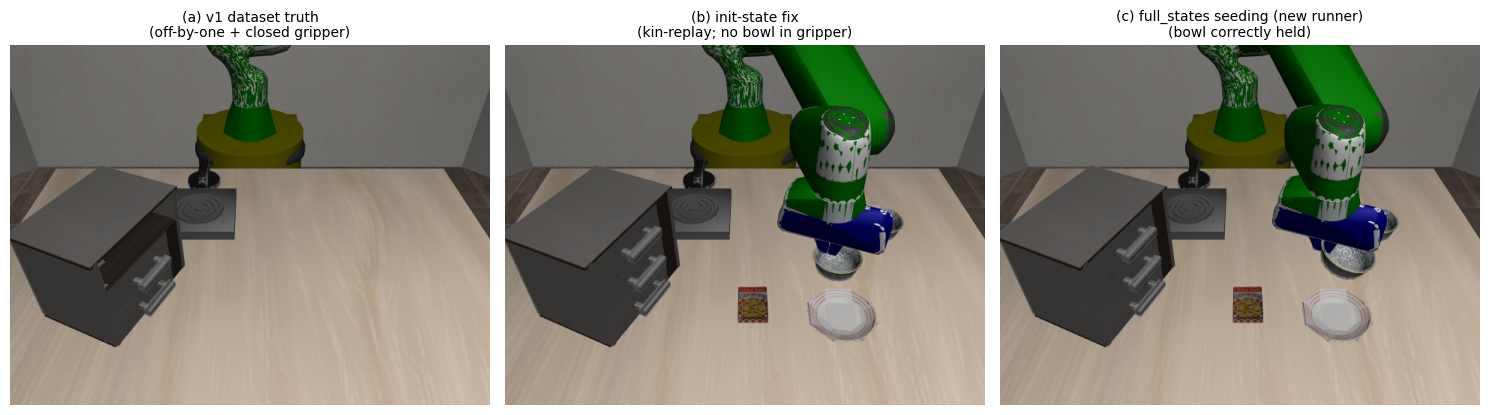

In [24]:
# Pick a demo and a progress where the bowl should be in the gripper.
VERIFY_SPLIT = SPLIT
VERIFY_TASK = TASK
VERIFY_DEMO = DEMO
VERIFY_PROGRESS = 0.65

verify_demo = load_demo(hdf5_for_row(demo_rows.iloc[0]), VERIFY_DEMO)
verify_model = mujoco.MjModel.from_xml_path(materialise_mjcf(verify_demo.model_xml))
T_v = verify_demo.arm_qpos.shape[0]
fail_idx_v = max(1, min(int(VERIFY_PROGRESS * (T_v - 1)), T_v - 1))
print(f"demo T={T_v}  verifying at progress={VERIFY_PROGRESS} -> fail_idx={fail_idx_v}")

# (a) buggy: init_state[:nq]
data_a = mujoco.MjData(verify_model)
data_a.qpos[:verify_model.nq] = verify_demo.init_state[:verify_model.nq]
data_a.qvel[:verify_model.nv] = verify_demo.init_state[verify_model.nq:verify_model.nq + verify_model.nv]
mujoco.mj_forward(verify_model, data_a)

# (b) init-state-fix only: kinematic replay starting from corrected init_state
from planner.experiments.libero.naming import resolve_model_handles
data_b = mujoco.MjData(verify_model)
data_b.qpos[:verify_model.nq] = verify_demo.init_state[1:1 + verify_model.nq]
data_b.qvel[:verify_model.nv] = verify_demo.init_state[1 + verify_model.nq:1 + verify_model.nq + verify_model.nv]
hb = resolve_model_handles(verify_model)
for t in range(fail_idx_v + 1):
    for adr, q in zip(hb.arm_qpos_adrs, verify_demo.arm_qpos[t]):
        data_b.qpos[adr] = q
    for adr, q in zip(hb.finger_qpos_adrs, verify_demo.finger_qpos[t]):
        data_b.qpos[adr] = q
    for adr in hb.arm_dof_adrs:
        data_b.qvel[adr] = 0.0
    mujoco.mj_forward(verify_model, data_b)

# (c) both fixes + full_states seeding (the new runner path)
data_c = mujoco.MjData(verify_model)
fc_state = verify_demo.full_states[fail_idx_v]
data_c.qpos[:verify_model.nq] = fc_state[1:1 + verify_model.nq]
data_c.qvel[:verify_model.nv] = fc_state[1 + verify_model.nq:1 + verify_model.nq + verify_model.nv]
mujoco.mj_forward(verify_model, data_c)

# Bowl xyz under each
bowl_bid = mujoco.mj_name2id(verify_model, mujoco.mjtObj.mjOBJ_BODY, "akita_black_bowl_1_main")
bowl_qadr = int(verify_model.jnt_qposadr[int(verify_model.body_jntadr[bowl_bid])])
print(f"\nbowl xyz under each method:")
print(f"  (a) buggy:                {data_a.qpos[bowl_qadr:bowl_qadr+3]}")
print(f"  (b) init-state-fix only:  {data_b.qpos[bowl_qadr:bowl_qadr+3]}")
print(f"  (c) both fixes:           {data_c.qpos[bowl_qadr:bowl_qadr+3]}")

def render(d):
    rr = mujoco.Renderer(verify_model, height=480, width=640)
    rr.update_scene(d, camera="agentview")
    return rr.render()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, d, title in zip(
    axes, [data_a, data_b, data_c],
    [f"(a) v1 dataset truth\n(off-by-one + closed gripper)",
     f"(b) init-state fix\n(kin-replay; no bowl in gripper)",
     f"(c) full_states seeding (new runner)\n(bowl correctly held)"]):
    ax.imshow(render(d))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

bowl_z pre: 1.001  ->  post: 0.909  (drop = 0.092 m)
raw contacts collected: 24


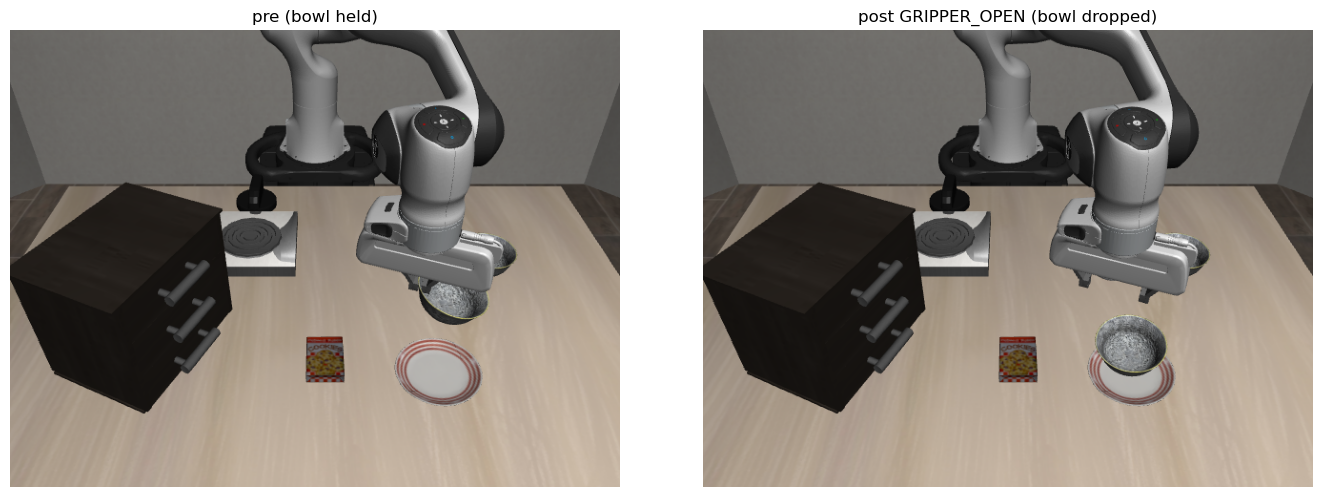

In [25]:
# GRIPPER_OPEN trial under the new runner — pre vs post agentview
from planner.experiments.config import FailureConfig, FailureMode
from planner.experiments.libero.runner import LiberoRunner, LiberoTrialConfig

fc = FailureConfig(mode=FailureMode.GRIPPER_OPEN)
cfg = LiberoTrialConfig(fail_progress=VERIFY_PROGRESS, failure_configs=[fc],
                         seed=0, resistance_mode="gravcomp_pd")
runner = LiberoRunner(verify_demo, cfg)
try:
    sample = runner.run()
    bowl_z_post = float(runner.data.qpos[bowl_qadr + 2])
finally:
    runner.close()

bowl_z_pre = float(verify_demo.full_states[fail_idx_v][1 + bowl_qadr + 2])
print(f"bowl_z pre: {bowl_z_pre:.3f}  ->  post: {bowl_z_post:.3f}  (drop = {bowl_z_pre - bowl_z_post:.3f} m)")
print(f"raw contacts collected: {len(sample.aggregate_contacts)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(sample.pre_failure_rgb); axes[0].set_title("pre (bowl held)"); axes[0].axis("off")
axes[1].imshow(sample.post_failure_rgb); axes[1].set_title("post GRIPPER_OPEN (bowl dropped)"); axes[1].axis("off")
plt.tight_layout()
plt.show()

### 7a. Demo playback — LIBERO truth vs our reproduction

The frames above are static. To verify the fix at the *trajectory* level, render an mp4 that puts LIBERO's recorded `obs/agentview_rgb` (truth) next to our render of the demo's full sim state at every step (reproduction). Powered by `scripts/libero/play_demo_compare.py`. Files land in `out/libero_videos/play/` (gitignored).

In [26]:
import subprocess
from IPython.display import Video, display

PLAY_HDF5 = hdf5_for_row(demo_rows.iloc[0])
PLAY_DEMO = DEMO
PLAY_OUT = f"out/libero_videos/play/{SPLIT}__{TASK}_demo__{PLAY_DEMO}.mp4"

if not os.path.exists(PLAY_OUT):
    print(f"rendering {PLAY_OUT} ...")
    cp = subprocess.run(
        ["python", "-m", "scripts.libero.play_demo_compare",
         "--hdf5", PLAY_HDF5, "--demo", PLAY_DEMO, "--output", PLAY_OUT],
        capture_output=True, text=True,
    )
    print(cp.stdout[-400:])
    if cp.returncode != 0:
        print("STDERR:", cp.stderr[-400:])
else:
    print(f"using cached {PLAY_OUT}")

display(Video(PLAY_OUT, embed=True, width=720,
              html_attributes="controls loop muted autoplay"))

using cached out/libero_videos/play/libero_spatial__pick_up_the_black_bowl_between_the_plate_and_the_ramekin_and_place_it_on_the_plate_demo__demo_0.mp4


## 7. Whole-split contact-cloud overlay (raw)

Top-down (x, y) hexbin of contact positions across many trials in one split. **No baseline filter applied** — this is the raw cloud, dominated by standing contacts. Apply the §3a entity-pair filter at trial-load time for a clean signal.

23244 points from 200 trials


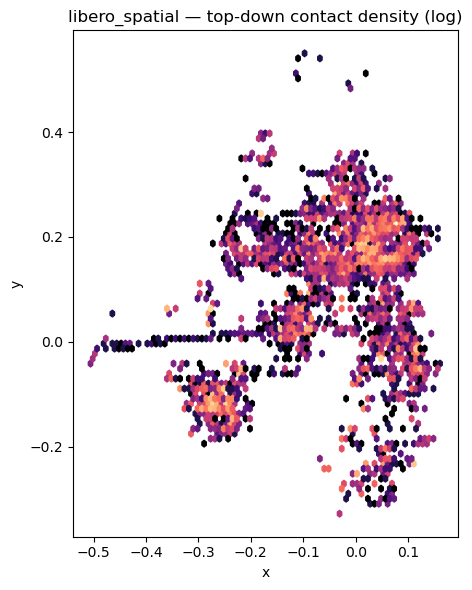

In [27]:
TARGET_SPLIT = "libero_spatial"
N_TRIALS = 200
MAX_CONTACTS_PER_TRIAL = 200

sample = manifest[manifest["split"] == TARGET_SPLIT].sample(N_TRIALS, random_state=0)
all_pts = []
for _, r in sample.iterrows():
    with np.load(os.path.join(ROOT, r["split"], r["npz_file"]), allow_pickle=True) as z:
        pts = z["contact_positions"]
    if len(pts) > MAX_CONTACTS_PER_TRIAL:
        idx = np.random.default_rng(0).choice(len(pts), MAX_CONTACTS_PER_TRIAL, replace=False)
        pts = pts[idx]
    all_pts.append(pts)
all_pts = np.concatenate(all_pts, axis=0) if all_pts else np.zeros((0, 3))
print(f"{len(all_pts)} points from {len(sample)} trials")

fig, ax = plt.subplots(figsize=(8, 6))
ax.hexbin(all_pts[:, 0], all_pts[:, 1], gridsize=80, bins="log", cmap="magma")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"{TARGET_SPLIT} — top-down contact density (log)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

---

## Where to go next

- Open `notebooks/inspect_libero.ipynb` for entity-level baseline-filtered contact clouds on a single trial.
- See `docs/libero_v1_dataset.md` for the full schema + label derivations.
- Density targets: `scripts/build_density_targets.py` (needs a per-task LIBERO grid).